<a href="https://colab.research.google.com/github/arsy25/ASHARAN-INVOICE-GENERATOR/blob/main/RESNET18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Full Colab-ready ResNet18 training (auto-detect dataset location, convert to .jpg, split, train)
# Requirements: Paste this into a single Colab cell and run.
!pip install -q torch torchvision pillow tqdm

import os, shutil, random
from pathlib import Path
from PIL import Image, UnidentifiedImageError
from tqdm import tqdm

import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models

# ---------------- Config ----------------
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

ROOT = Path("/content")
# possible dataset layouts to detect
PAIRS = [
    (ROOT / "cats", ROOT / "dogs"),
    (ROOT / "content" / "cats", ROOT / "content" / "dogs"),
    (ROOT / "train" / "cats", ROOT / "train" / "dogs"),
    (ROOT / "PetImages" / "Cat", ROOT / "PetImages" / "Dog"),
    (ROOT / "content" / "PetImages" / "Cat", ROOT / "content" / "PetImages" / "Dog"),
]

PROCESSED = ROOT / "processed"
IMG_EXT = ".jpg"
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = min(4, os.cpu_count() or 1)
NUM_EPOCHS = 10
LR = 1e-3
VAL_SPLIT = 0.2
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ---------------- Helpers ----------------
def find_dataset_base():
    for a, b in PAIRS:
        if a.exists() and b.exists():
            return a.parent
    # fallback: if single exists, return its parent
    for p in [ROOT / "cats", ROOT / "dogs", ROOT / "content" / "cats", ROOT / "content" / "dogs"]:
        if p.exists():
            return p.parent
    return None

def ensure_dir(p: Path):
    p.mkdir(parents=True, exist_ok=True)

def gather_files(folder: Path):
    return [p for p in folder.rglob("*") if p.is_file()]

def convert_image_to_jpg(src_path: Path, dst_path: Path, quality=95):
    try:
        with Image.open(src_path) as im:
            if im.mode != "RGB":
                im = im.convert("RGB")
            ensure_dir(dst_path.parent)
            im.save(dst_path.with_suffix(IMG_EXT), "JPEG", quality=quality)
            return True
    except Exception:
        return False

# ---------------- Preprocess ----------------
def prepare_dataset(src_base: Path):
    SRC_CAT = src_base / "cats" if (src_base / "cats").exists() else src_base / "Cat" if (src_base / "Cat").exists() else None
    SRC_DOG = src_base / "dogs" if (src_base / "dogs").exists() else src_base / "Dog" if (src_base / "Dog").exists() else None

    if not SRC_CAT or not SRC_DOG:
        raise FileNotFoundError(f"Couldn't locate both cats and dogs under {src_base}. Found: {list(src_base.iterdir())}")

    print("Source cat dir:", SRC_CAT)
    print("Source dog dir:", SRC_DOG)

    # clear processed
    if PROCESSED.exists():
        shutil.rmtree(PROCESSED)
    ensure_dir(PROCESSED / "train")
    ensure_dir(PROCESSED / "val")

    classes = [("cats", SRC_CAT), ("dogs", SRC_DOG)]
    summary = {}
    for cls_name, src in classes:
        files = gather_files(src)
        random.shuffle(files)
        n = len(files)
        split_idx = int(n * (1 - VAL_SPLIT))
        train_files = files[:split_idx]
        val_files = files[split_idx:]
        written_train = 0
        written_val = 0

        for subset_name, file_list in [("train", train_files), ("val", val_files)]:
            target_dir = PROCESSED / subset_name / cls_name
            ensure_dir(target_dir)
            for f in tqdm(file_list, desc=f"Processing {cls_name}/{subset_name}", unit="file"):
                dst = target_dir / f"{f.stem}{IMG_EXT}"
                if convert_image_to_jpg(f, dst):
                    if subset_name == "train":
                        written_train += 1
                    else:
                        written_val += 1
                else:
                    # skip invalid
                    continue
        summary[cls_name] = {"total": n, "train": written_train, "val": written_val}
    print("Preprocessing summary:", summary)
    return summary

# ---------------- Dataloaders ----------------
def get_dataloaders():
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(IMG_SIZE),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])
    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
    ])

    train_set = datasets.ImageFolder(PROCESSED / "train", transform=train_transform)
    val_set = datasets.ImageFolder(PROCESSED / "val", transform=val_transform)
    print("Detected classes:", train_set.classes)
    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)
    return train_loader, val_loader, train_set.classes

# ---------------- Model ----------------
def build_model(num_classes):
    model = models.resnet18(pretrained=True)
    for param in model.parameters():
        param.requires_grad = False
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

# ---------------- Train/Val ----------------
def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    running_corrects = 0
    total = 0
    for X, y in tqdm(loader, desc="Train", leave=False):
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        _, preds = outputs.max(1)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * X.size(0)
        running_corrects += (preds == y).sum().item()
        total += X.size(0)
    return running_loss / total if total else 0.0, running_corrects / total if total else 0.0

def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    running_corrects = 0
    total = 0
    with torch.no_grad():
        for X, y in tqdm(loader, desc="Val", leave=False):
            X, y = X.to(DEVICE), y.to(DEVICE)
            outputs = model(X)
            loss = criterion(outputs, y)
            _, preds = outputs.max(1)
            running_loss += loss.item() * X.size(0)
            running_corrects += (preds == y).sum().item()
            total += X.size(0)
    return running_loss / total if total else 0.0, running_corrects / total if total else 0.0

# ---------------- Main ----------------
def main():
    base = find_dataset_base()
    if base is None:
        raise FileNotFoundError("Couldn't auto-detect dataset base. Please upload cats & dogs under /content or /content/content or /content/train etc.")
    print("Auto-detected dataset base:", base)
    summary = prepare_dataset(base)

    train_loader, val_loader, classes = get_dataloaders()

    model = build_model(num_classes=len(classes)).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.fc.parameters(), lr=LR)

    best_val_acc = 0.0
    best_path = ROOT / "best_resnet18_cats_dogs.pth"

    for epoch in range(1, NUM_EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = validate(model, val_loader, criterion)
        print(f"Epoch {epoch}/{NUM_EPOCHS} | Train loss {train_loss:.4f} acc {train_acc:.4f} | Val loss {val_loss:.4f} acc {val_acc:.4f}")
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_acc": val_acc,
                "classes": classes
            }, best_path)
            print("Saved best model to", best_path)

    print("Done. Best val acc:", best_val_acc)
    print("Model path:", best_path)

if __name__ == "__main__":
    main()

Device: cpu
Auto-detected dataset base: /content/content
Source cat dir: /content/content/cats
Source dog dir: /content/content/dogs


Processing dogs/val: 100%|██████████| 3/3 [00:00<00:00, 49.91file/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Preprocessing summary: {'cats': {'total': 11, 'train': 8, 'val': 3}, 'dogs': {'total': 11, 'train': 8, 'val': 3}}
Detected classes: ['cats', 'dogs']


Epoch 1/10 | Train loss 0.9640 acc 0.3125 | Val loss 0.8427 acc 0.1667
Saved best model to /content/best_resnet18_cats_dogs.pth


Epoch 2/10 | Train loss 0.7636 acc 0.5000 | Val loss 0.7618 acc 0.5000
Saved best model to /content/best_resnet18_cats_dogs.pth


...

Epoch 6/10 | Train loss 0.5582 acc 0.9375 | Val loss 0.5167 acc 0.8333
Saved best model to /content/best_resnet18_cats_dogs.pth


Epoch 7/10 | Train loss 0.4905 acc 0.7500 | Val loss 0.4697 acc 0.8333


Epoch 8/10 | Train loss 0.4492 acc 0.7500 | Val loss 0.4235 acc 0.8333


Epoch 9/10 | Train loss 0.3602 acc 0.9375 | Val loss 0.3887 acc 1.0000
Saved best model to /content/best_resnet18_cats_dogs.pth


Epoch 10/10 | Train loss 0.4382 acc 0.7500 | Val loss 0.3581 acc 1.0000
Done. Best val acc: 1.0
Model path: /content/best_resnet18_cats_dogs.pth


Device: cpu
Classes: ['cats', 'dogs']
Num val samples: 6


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Loaded model from checkpoint epoch: 9 val_acc: 1.0

Classification Report:
               precision    recall  f1-score   support

        cats     1.0000    1.0000    1.0000         3
        dogs     1.0000    1.0000    1.0000         3

    accuracy                         1.0000         6
   macro avg     1.0000    1.0000    1.0000         6
weighted avg     1.0000    1.0000    1.0000         6

Confusion Matrix:
 [[3 0]
 [0 3]]
Normalized Confusion Matrix:
 [[1. 0.]
 [0. 1.]]


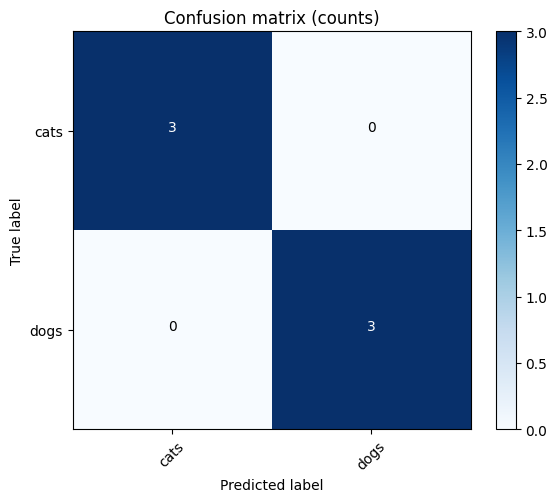

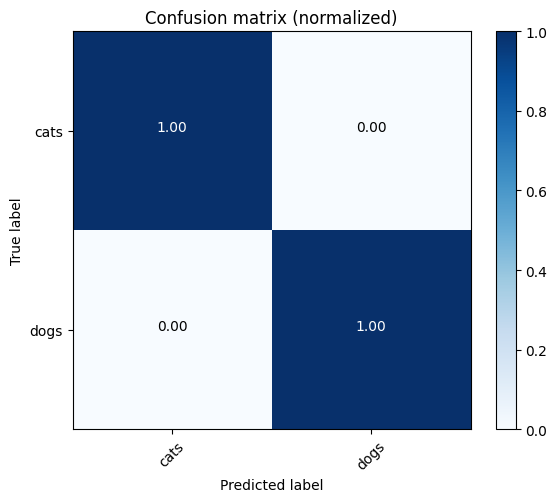

Saved classification report and confusion matrices to /content/evaluation
No example image found at /content/example_infer.jpg — to run inference, upload image to that path or set example_path to an existing file.

Done evaluation cell. To save to Drive call: save_to_drive()


In [ ]:
# Evaluation, metrics, confusion matrix, and inference utilities for the trained ResNet18 model
!pip install -q scikit-learn matplotlib pillow

import os
from pathlib import Path
import torch
import torch.nn as nn
from torchvision import transforms, models
from torchvision import datasets
from torch.utils.data import DataLoader
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
from PIL import Image

ROOT = Path("/content")
PROCESSED = ROOT / "processed"
BEST_MODEL_PATH = ROOT / "best_resnet18_cats_dogs.pth"
IMG_SIZE = 224
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ---------------- Load model helper ----------------
def load_trained_model(model_path: Path, num_classes=2):
    if not model_path.exists():
        raise FileNotFoundError(f"Model file not found: {model_path}")
    # Rebuild architecture
    model = models.resnet18(pretrained=False)  # weights not needed; we'll load state_dict
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    checkpoint = torch.load(model_path, map_location=DEVICE)
    model.load_state_dict(checkpoint["model_state_dict"])
    model = model.to(DEVICE)
    model.eval()
    return model, checkpoint

# ---------------- Prepare val dataloader (same transforms used in training) ----------------
val_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

val_dir = PROCESSED / "val"
if not val_dir.exists():
    raise FileNotFoundError(f"Validation folder not found: {val_dir}. Run preprocessing/training first.")

val_dataset = datasets.ImageFolder(val_dir, transform=val_transform)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2)
class_names = val_dataset.classes
print("Classes:", class_names)
print("Num val samples:", len(val_dataset))

# ---------------- Evaluation: get preds and targets ----------------
def evaluate_model(model, loader):
    model.eval()
    all_preds = []
    all_targets = []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(DEVICE)
            outputs = model(X)
            preds = outputs.argmax(dim=1).cpu().numpy()
            all_preds.extend(preds.tolist())
            all_targets.extend(y.numpy().tolist())
    return np.array(all_targets), np.array(all_preds)

# Load model
model, checkpoint = load_trained_model(BEST_MODEL_PATH, num_classes=len(class_names))
print("Loaded model from checkpoint epoch:", checkpoint.get("epoch", "N/A"), "val_acc:", checkpoint.get("val_acc", "N/A"))

# Run evaluation
y_true, y_pred = evaluate_model(model, val_loader)

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("\nClassification Report:\n", report)

# Confusion matrix (raw and normalized)
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
print("Confusion Matrix:\n", cm)
print("Normalized Confusion Matrix:\n", np.round(cm_norm, 3))

# Plot confusion matrix
def plot_confusion(cm, classes, normalize=False, cmap=plt.cm.Blues, title="Confusion matrix"):
    if normalize:
        cm_to_plot = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
    else:
        cm_to_plot = cm
    plt.figure(figsize=(6,5))
    plt.imshow(cm_to_plot, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = ".2f" if normalize else "d"
    thresh = cm_to_plot.max() / 2.
    for i, j in np.ndindex(cm_to_plot.shape):
        plt.text(j, i, format(cm_to_plot[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm_to_plot[i, j] > thresh else "black")
    plt.ylabel("True label")
    plt.xlabel("Predicted label")
    plt.tight_layout()
    return plt

# show both
plot_confusion(cm, class_names, normalize=False, title="Confusion matrix (counts)").show()
plot_confusion(cm, class_names, normalize=True, title="Confusion matrix (normalized)").show()

# ---------------- Save report to file ----------------
out_dir = ROOT / "evaluation"
out_dir.mkdir(exist_ok=True)
(report_file := out_dir / "classification_report.txt").write_text(report)
np.savetxt(out_dir / "confusion_matrix.csv", cm, fmt="%d", delimiter=",")
np.savetxt(out_dir / "confusion_matrix_normalized.csv", cm_norm, fmt="%.6f", delimiter=",")
print("Saved classification report and confusion matrices to", out_dir)

# ---------------- Single-image inference helper ----------------
inference_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485,0.456,0.406], std=[0.229,0.224,0.225]),
])

def predict_image(model, img_path: str, class_names=class_names):
    img = Image.open(img_path).convert("RGB")
    x = inference_transform(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out = model(x)
        probs = torch.softmax(out, dim=1).cpu().numpy()[0]
        pred_idx = int(np.argmax(probs))
    return {"pred_index": pred_idx, "pred_label": class_names[pred_idx], "probabilities": probs.tolist()}

# ---------------- Example: inference on uploaded file ----------------
# To test: upload an image via Colab file upload UI or copy a path here.
example_path = "/content/example_infer.jpg"  # change if you uploaded a file
if Path(example_path).exists():
    print("Running example inference on", example_path)
    res = predict_image(model, example_path)
    print(res)
else:
    print("No example image found at", example_path, "— to run inference, upload image to that path or set example_path to an existing file.")

# ---------------- (Optional) Save everything to Google Drive ----------------
def save_to_drive(save_dir="/content/drive/MyDrive/resnet_cats_dogs_eval"):
    try:
        from google.colab import drive
        drive.mount('/content/drive', force_remount=False)
    except Exception as e:
        print("Drive mount error:", e)
        return
    target = Path(save_dir)
    target.mkdir(parents=True, exist_ok=True)
    # copy artifacts
    shutil.copy(BEST_MODEL_PATH, target / BEST_MODEL_PATH.name)
    shutil.copy(report_file, target / report_file.name)
    shutil.copy(out_dir / "confusion_matrix.csv", target / "confusion_matrix.csv")
    shutil.copy(out_dir / "confusion_matrix_normalized.csv", target / "confusion_matrix_normalized.csv")
    print("Saved model and reports to Drive at", target)

print("\nDone evaluation cell. To save to Drive call: save_to_drive()")